# EXAMEN DE PRÁCTICAS - ESTADÍSTICA

**Contexto:** Un estudio biológico sobre tres especies de pingüinos en la Antártida. Es un clásico para sustituir al antiguo dataset "Iris".

* **Fichero:** `penguins.csv`
* **Variables a usar:** `Masa_Corporal` (en gramos) y `Longitud_Aleta` (en mm).

### Ejercicio 1 (0.25 pts.)
Importa el fichero `penguins.csv` y muestra el principio y final. ¿Qué tipo de variables son la masa corporal y la longitud de la aleta?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pinguinos = pd.read_csv("penguins.csv")

print(pinguinos.head())
print(pinguinos.tail())
print(pinguinos.info())

   Masa_Corporal  Longitud_Aleta
0           3900             186
1           3800             195
2           4250             205
3           3450             190
4           3650             195
    Masa_Corporal  Longitud_Aleta
45           4700             214
46           3500             187
47           3950             196
48           4150             125
49           5050             217
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Masa_Corporal   50 non-null     int64
 1   Longitud_Aleta  50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes
None


Respuesta: Las variables son de tipo int64 las dos

### Ejercicio 2 (0.3 pts.)
Calcula el histograma de la `Masa_Corporal`. Corta esta variable basándote en los intervalos (bins) del histograma y muestra la tabla de frecuencias absolutas de la variable cortada. ¿Qué sacas en claro de la distribución del peso?

<Axes: >

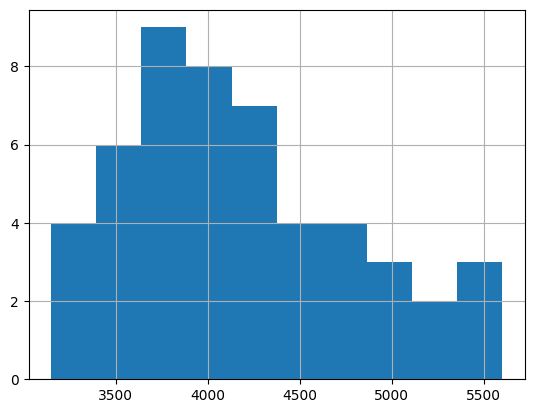

In [3]:
# Escribe aquí tu código y respuestas
Masa_Corporal = pinguinos["Masa_Corporal"]
Masa_Corporal.hist()


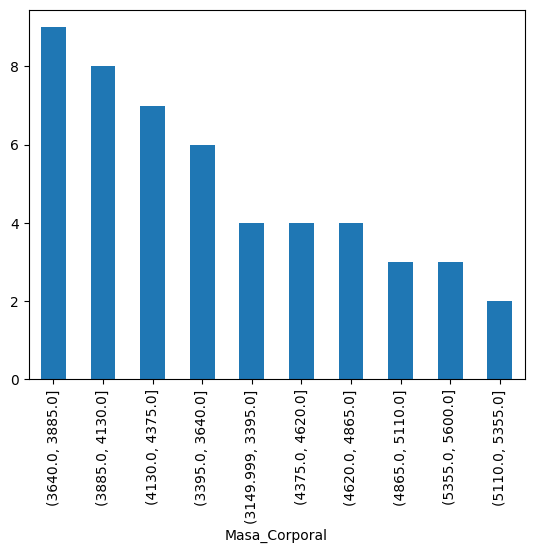

In [4]:
Masa_Corporal_datos_agrupados=pd.cut(
    Masa_Corporal,
    bins = np.histogram(Masa_Corporal)[1],
    right=True,
    include_lowest=True
)
Masa_Corporal_datos_agrupados

counts = Masa_Corporal_datos_agrupados.value_counts()
counts.plot(kind='bar')
plt.show()

### Ejercicio 3 (0.25 pts.)
Estudia los cuartiles y detecta si existen datos atípicos en la `Longitud_Aleta`. Compruébalo dibujando su diagrama de caja-bigotes (boxplot).

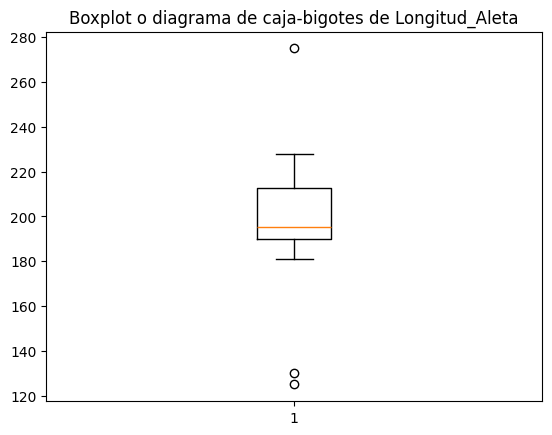

In [5]:
# Escribe aquí tu código y respuestas
Longitud_Aleta=pinguinos["Longitud_Aleta"]
Q1=np.quantile(Longitud_Aleta,0.25)
Q2=np.quantile(Longitud_Aleta,0.5)
Q3=np.quantile(Longitud_Aleta,0.75)
[Q1,Q2,Q3]

plt.boxplot(Longitud_Aleta) 
plt.title('Boxplot o diagrama de caja-bigotes de Longitud_Aleta') 
plt.show()

Como se observa si que existe algunos datos atipicos

In [6]:
R=Q3-Q1
R
[o1,o2]=[Q1-1.5*R,Q3+1.5*R]
[o1,o2]   # La "o" viene de "outlier", que es la forma inglesa de "valor atípico"

Longitud_Aleta_atipicos = Longitud_Aleta[(Longitud_Aleta >= o2) | (Longitud_Aleta <= o1)]
Longitud_Aleta_atipicos

16    130
27    275
48    125
Name: Longitud_Aleta, dtype: int64

### Ejercicio 4 (0.25 pts.)
Clasifica `Masa_Corporal` en tres categorías: **Ligero** (hasta 3500g), **Pesado** (más de 5000g) y **Estándar** (el resto). Clasifica `Longitud_Aleta` en dos: **Aleta_Corta** (hasta 200mm) y **Aleta_Larga** (más de 200mm).

In [7]:
# Escribe aquí tu código y respuestas


pinguinos['Cat_Masa'] = "Estándar" # Valor por defecto
pinguinos.loc[pinguinos['Masa_Corporal'] <= 3500, 'Cat_Masa'] = "Ligero"
pinguinos.loc[pinguinos['Masa_Corporal'] > 5000, 'Cat_Masa'] = "Pesado"

# Para la Longitud de la Aleta
pinguinos['Cat_Aleta'] = np.where(pinguinos['Longitud_Aleta'] <= 200, "Aleta_Corta", "Aleta_Larga")



### Ejercicio 5 (0.35 pts.)
¿Existe relación entre el tipo de peso y el tamaño de la aleta? Crea una tabla de contingencia cruzando ambas variables categóricas y coméntala.

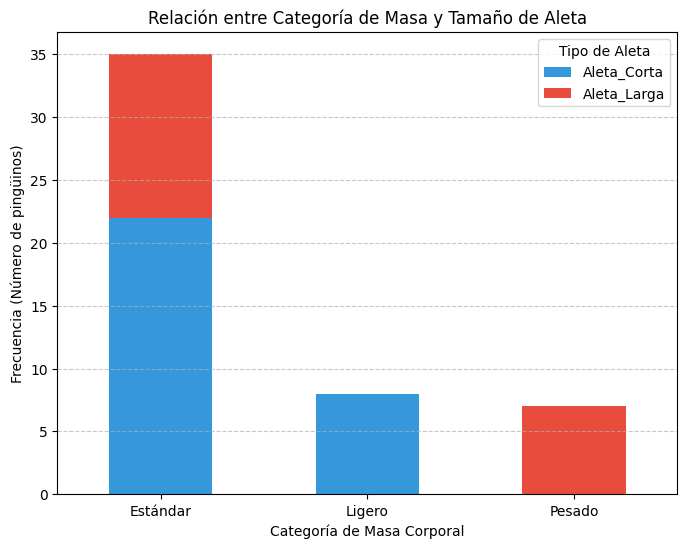

In [8]:
# Escribe aquí tu código y respuestas


n_ij = pd.crosstab(pinguinos['Cat_Masa'], pinguinos['Cat_Aleta'])

# 2. Generamos el gráfico de barras apiladas
n_ij.plot(kind='bar', stacked=True, color=['#3498db', '#e74c3c'], figsize=(8, 6))

# 3. Personalización corregida
plt.title('Relación entre Categoría de Masa y Tamaño de Aleta')
plt.xlabel('Categoría de Masa Corporal')
plt.ylabel('Frecuencia (Número de pingüinos)')
plt.xticks(rotation=0) # Para que "Ligero", "Estándar" y "Pesado" se lean en horizontal
plt.legend(title='Tipo de Aleta')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Como se observa en el gráfico, la mayoría de los pingüinos con aletas cortas tienen una masa corporal ligera, mientras que los pingüinos con aletas largas tienden a tener una masa corporal pesada. Esto sugiere una posible relación entre la longitud de las aletas y la masa corporal en esta población de pingüinos. En cuanto a los de peso estandar se ve que es casi un 50/50 de aleta larga o corta

### Ejercicio 6 (0.35 pts.)
¿Representa bien los datos la recta de regresión de la `Longitud_Aleta` respecto a la `Masa_Corporal`? Lleva a cabo un modelo logarítmico $L(m) = a \ln(m) + b$ e indica su bondad de ajuste ($R^2$).

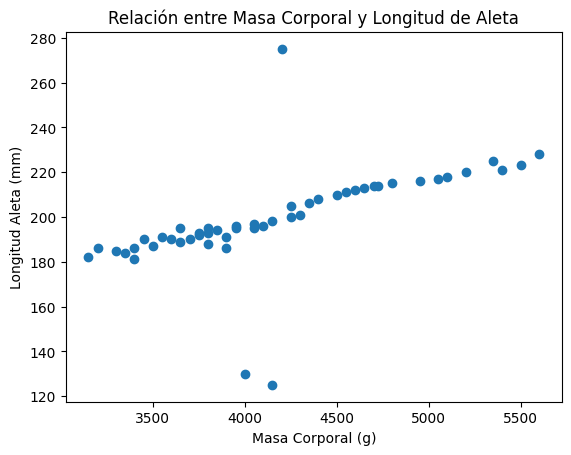

In [9]:
# Escribe aquí tu código y respuestas
plt.scatter(pinguinos["Masa_Corporal"], pinguinos["Longitud_Aleta"])
plt.xlabel("Masa Corporal (g)")
plt.ylabel("Longitud Aleta (mm)")
plt.title("Relación entre Masa Corporal y Longitud de Aleta")
plt.show()

Coeficiente a (pendiente): 0.019426950807885115
Coeficiente b (intersección): 119.48456729713


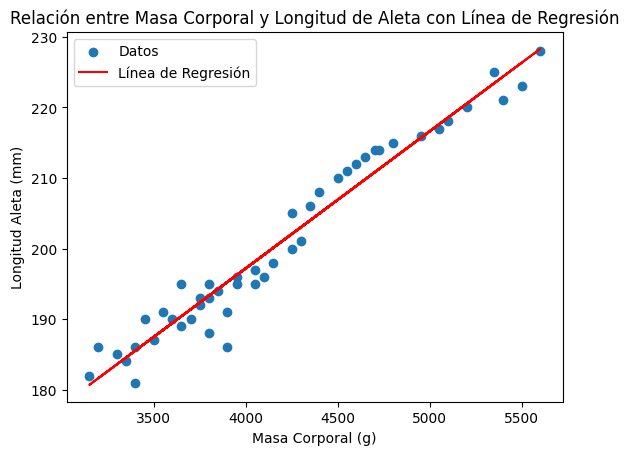

In [ ]:
x = pinguinos["Masa_Corporal"]
y = pinguinos["Longitud_Aleta"] 

a,b = np.polyfit(x, y, 1)
print(f"Coeficiente a (pendiente): {a}")
print(f"Coeficiente b (intersección): {b}")

plt.scatter(x, y, label='Datos')
plt.plot(x, a*x + b, color='red', label='Línea de Regresión')
plt.xlabel("Masa Corporal (g)")
plt.ylabel("Longitud Aleta (mm)")
plt.title("Relación entre Masa Corporal y Longitud de Aleta con Línea de Regresión")
plt.legend()
plt.show()

Como observamos no se ajusta del todo, asi que vamos a hacer la forma logaritmica que podria encajar mejor

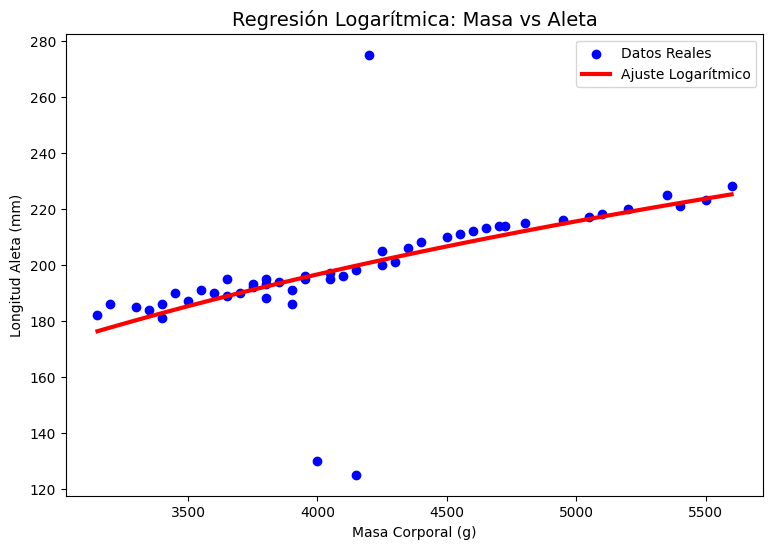

In [31]:
x = pinguinos["Masa_Corporal"]
y = pinguinos["Longitud_Aleta"]


a, b = np.polyfit(np.log(x), y, 1)
plt.figure(figsize=(9, 6))
plt.scatter(x, y, label='Datos Reales', color='blue')
x_curva = np.linspace(x.min(), x.max(), 100)
y_curva = a * np.log(x_curva) + b

plt.plot(x_curva, y_curva, color='red', lw=3, label='Ajuste Logarítmico')


plt.title('Regresión Logarítmica: Masa vs Aleta', fontsize=14)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud Aleta (mm)')
plt.legend()
plt.show()

In [32]:
y_pred = a * np.log(x) + b
residuos = y - y_pred
ss_res = np.sum(residuos**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_cuadrado = 1 - (ss_res / ss_tot)

print(f"Ecuación: L(m) = {a:.4f} * ln(m) + ({b:.4f})")
print(f"Bondad de ajuste (R²): {r_cuadrado:.4f}")

Ecuación: L(m) = 84.9725 * ln(m) + (-508.2210)
Bondad de ajuste (R²): 0.3317


Como observamos al haber valores atipicos que se salen tanto de la nube central la bondad de ajuste es bastante baja pero si los eliminamos

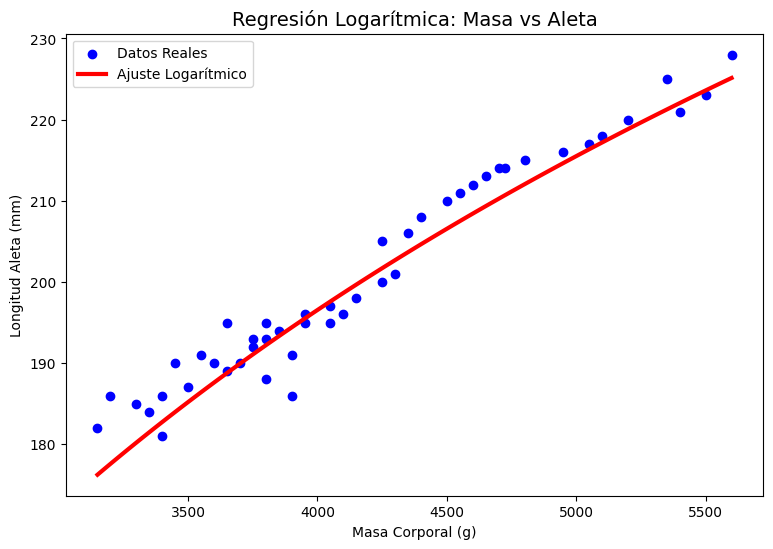

Ecuación: L(m) = 84.9725 * ln(m) + (-508.2210)
Bondad de ajuste (R²): 0.9332


In [37]:
pinguinos_filtrados = pinguinos[(pinguinos['Longitud_Aleta'] > o1) & (pinguinos['Longitud_Aleta'] < o2)] # Filtramos los datos para eliminar los valores atípicos de la longitud de la aleta

x = pinguinos_filtrados['Masa_Corporal']
y = pinguinos_filtrados['Longitud_Aleta']

plt.figure(figsize=(9, 6))
plt.scatter(x, y, label='Datos Reales', color='blue')
x_curva = np.linspace(x.min(), x.max(), 100)
y_curva = a * np.log(x_curva) + b

plt.plot(x_curva, y_curva, color='red', lw=3, label='Ajuste Logarítmico')


plt.title('Regresión Logarítmica: Masa vs Aleta', fontsize=14)
plt.xlabel('Masa Corporal (g)')
plt.ylabel('Longitud Aleta (mm)')
plt.legend()
plt.show()

y_pred = a * np.log(x) + b
residuos = y - y_pred
ss_res = np.sum(residuos**2)
ss_tot = np.sum((y - np.mean(y))**2)
r_cuadrado = 1 - (ss_res / ss_tot)

print(f"Ecuación: L(m) = {a:.4f} * ln(m) + ({b:.4f})")
print(f"Bondad de ajuste (R²): {r_cuadrado:.4f}")

Como observamos ahora la bondad ha subido muchisimo ya que esos valores nos quitaban mucha al ser casi imposible solucinar esa ecuacion para esas soluciones

### Ejercicio 7 (0.25 pts.)
Predice la longitud de aleta de un pingüino que pesa 4200 g, usando los dos modelos anteriores.

Resultados para un pingüino de 4200g:
---------------------------------------------
Predicción Lineal:      199.74 mm
Predicción Logarítmica: 200.69 mm


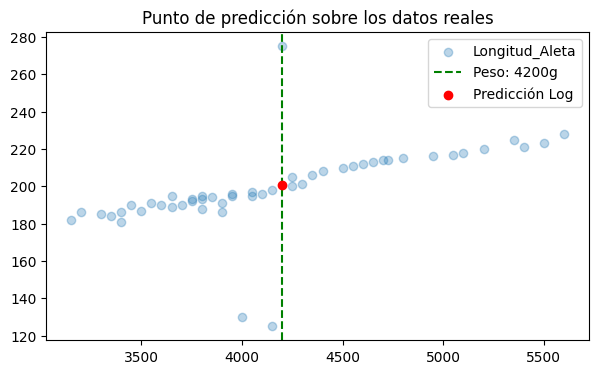

In [36]:
peso_objetivo = 4200

# --- 1. MODELO LINEAL SIMPLE ---
# Calculamos coeficientes: y = m*x + n
coef_lin = np.polyfit(pinguinos['Masa_Corporal'], pinguinos['Longitud_Aleta'], 1)
m, n = coef_lin
pred_lineal = m * peso_objetivo + n

# --- 2. MODELO LOGARÍTMICO ---
# Calculamos coeficientes: L = a*ln(m) + b
# Usamos np.log() para el logaritmo natural
a, b = np.polyfit(np.log(pinguinos['Masa_Corporal']), pinguinos['Longitud_Aleta'], 1) # Necesario ya que hemos eliminado a y b en la sección anterior para quitar los datos atipicos
pred_log = a * np.log(peso_objetivo) + b

print(f"Resultados para un pingüino de {peso_objetivo}g:")
print(f"---------------------------------------------")
print(f"Predicción Lineal:      {pred_lineal:.2f} mm")
print(f"Predicción Logarítmica: {pred_log:.2f} mm")

plt.figure(figsize=(7,4))
plt.scatter(x='Masa_Corporal', y='Longitud_Aleta', data=pinguinos, alpha=0.3)
plt.axvline(peso_objetivo, color='green', linestyle='--', label=f'Peso: {peso_objetivo}g')
plt.scatter([peso_objetivo], [pred_log], color='red',zorder=5, label='Predicción Log')
plt.legend()
plt.title('Punto de predicción sobre los datos reales')
plt.show()